# Dataset UCI-HAR

In [3]:
import pandas as pd
import numpy as np
import json
import os

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

In [4]:
ruta_archivo_csv = "Old Datasets/GRU-INC/UCI-HAR/UCI HAR Dataset/UCI HAR Dataset/combined_data.csv"

df = pd.read_csv(ruta_archivo_csv)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 561 entries, tBodyAcc-mean()-X to  angle(Z-gravityMean)
dtypes: float64(561)
memory usage: 44.1 MB


In [5]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),angle(tBodyAccMean-gravity),angle(tBodyAccJerkMean)-gravityMean),angle(tBodyGyroMean-gravityMean),angle(tBodyGyroJerkMean-gravityMean),angle(X-gravityMean),angle(Y-gravityMean),angle(Z-gravityMean)
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [7]:
ruta_archivo_csv = "Old Datasets/GRU-INC/UCI-HAR/UCI HAR Dataset/UCI HAR Dataset/combined_targets.csv"

dt = pd.read_csv(ruta_archivo_csv)
dt.head()

,target
0,5
1,5
2,5
3,5
4,5


In [10]:
# Realizar la unión de las tablas
users = pd.concat([df, dt], axis=1)
users.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),angle(tBodyAccMean-gravity),angle(tBodyAccJerkMean)-gravityMean),angle(tBodyGyroMean-gravityMean),angle(tBodyGyroJerkMean-gravityMean),angle(X-gravityMean),angle(Y-gravityMean),angle(Z-gravityMean),target
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5


#### Calculo de valores no nulos

In [11]:
# Agrupar por la columna "target" y calcular el número de datos no nulos por columna
counts = users.groupby("target").count()

# Calcular la suma de valores nulos por columna
null_counts = users.groupby("target").apply(lambda x: x.isnull().sum())

# Mostrar el número de datos no nulos
counts.head(20)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),angle(tBodyAccMean-gravity),angle(tBodyAccJerkMean)-gravityMean),angle(tBodyGyroMean-gravityMean),angle(tBodyGyroJerkMean-gravityMean),angle(X-gravityMean),angle(Y-gravityMean),angle(Z-gravityMean)
target,,,,,,,,,,,,,,,,,,,,,
1,1722,1722,1722,1722,1722,1722,1722,1722,1722,1722,...,1722,1722,1722,1722,1722,1722,1722,1722,1722,1722
2,1544,1544,1544,1544,1544,1544,1544,1544,1544,1544,...,1544,1544,1544,1544,1544,1544,1544,1544,1544,1544
3,1406,1406,1406,1406,1406,1406,1406,1406,1406,1406,...,1406,1406,1406,1406,1406,1406,1406,1406,1406,1406
4,1777,1777,1777,1777,1777,1777,1777,1777,1777,1777,...,1777,1777,1777,1777,1777,1777,1777,1777,1777,1777
5,1906,1906,1906,1906,1906,1906,1906,1906,1906,1906,...,1906,1906,1906,1906,1906,1906,1906,1906,1906,1906
6,1944,1944,1944,1944,1944,1944,1944,1944,1944,1944,...,1944,1944,1944,1944,1944,1944,1944,1944,1944,1944


Nos quedamos con las actividades que nos interesan:
- Caminar = 1. 
- Subir escaleras = 2.
- Bajar escaleras = 3.

In [24]:
user1 = users.loc[(users["target"] == 1) | (users["target"] == 2) | (users["target"] == 3)]

Filtramos las columnas que nos interesan: 
-	tBodyAcc-mean() para los ejes X, Y y Z. 
-	tBodyGyro-mean() para los ejes X, Y y Z. 

In [25]:
user1.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),angle(tBodyAccMean-gravity),angle(tBodyAccJerkMean)-gravityMean),angle(tBodyGyroMean-gravityMean),angle(tBodyGyroJerkMean-gravityMean),angle(X-gravityMean),angle(Y-gravityMean),angle(Z-gravityMean),target
78,0.282022,-0.037696,-0.134897,-0.328280,-0.137153,-0.189086,-0.404875,-0.176791,-0.199474,-0.154731,...,-0.312137,-0.673951,-0.160883,0.564736,0.912473,-0.412836,-0.773707,0.252432,0.044099,1
79,0.255841,-0.064550,-0.095186,-0.229207,0.016506,-0.260311,-0.276764,0.009066,-0.287367,-0.154731,...,-0.176625,-0.584284,-0.021977,0.506609,-0.700053,-0.840943,-0.767163,0.256919,0.044638,1
80,0.254867,0.003815,-0.123658,-0.275158,0.013080,-0.284371,-0.341341,-0.026013,-0.320272,-0.175559,...,-0.365417,-0.696201,0.372041,-0.106184,-0.923835,0.344459,-0.757414,0.264452,0.039417,1
81,0.343370,-0.014446,-0.167377,-0.229924,0.173911,-0.213388,-0.282882,0.144693,-0.237987,-0.152773,...,-0.203301,-0.546873,-0.378574,-0.582073,-0.886349,0.063337,-0.762534,0.260850,0.039735,1
82,0.276240,-0.029638,-0.142616,-0.226577,0.164288,-0.122545,-0.239526,0.140287,-0.148617,-0.152773,...,0.046239,-0.269192,-0.072906,0.656842,-0.291200,0.077922,-0.763968,0.259629,0.041412,1


In [31]:
# Seleccionar las primeras tres columnas y la última columna
user1 = user1.iloc[:, [0, 1, 2, 423, 424, 425, -1]]
user1.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,fBodyGyro-mean()-X,fBodyGyro-mean()-Y,fBodyGyro-mean()-Z,target
78,0.282022,-0.037696,-0.134897,-0.184781,-0.198024,-0.307558,1
79,0.255841,-0.064550,-0.095186,-0.204510,-0.245831,-0.311178,1
80,0.254867,0.003815,-0.123658,-0.317082,-0.208159,-0.185798,1
81,0.343370,-0.014446,-0.167377,-0.162211,0.026553,-0.180469,1
82,0.276240,-0.029638,-0.142616,-0.237106,0.047211,-0.257958,1


In [33]:
nuevos_nombres = ['Ax', 'Ay', 'Az', 'Gx', 'Gy', 'Gz', 'target']
user1.columns = nuevos_nombres
user1.head()

,Ax,Ay,Az,Gx,Gy,Gz,target
78,0.282022,-0.037696,-0.134897,-0.184781,-0.198024,-0.307558,1
79,0.255841,-0.064550,-0.095186,-0.204510,-0.245831,-0.311178,1
80,0.254867,0.003815,-0.123658,-0.317082,-0.208159,-0.185798,1
81,0.343370,-0.014446,-0.167377,-0.162211,0.026553,-0.180469,1
82,0.276240,-0.029638,-0.142616,-0.237106,0.047211,-0.257958,1


# Preparación de los datos

#### Comprobación de las columnas del sensor Acelerómetro

In [34]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['Ax', 'Ay', 'Az']] = user1[['Ax', 'Ay', 'Az']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

/opt/Anaconda/anaconda3/lib/python3.9/site-packages/pandas/core/frame.py:3641: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


,Ax,Ay,Az,Gx,Gy,Gz,target
78,0.282022,-0.037696,-0.134897,-0.184781,-0.198024,-0.307558,1
79,0.255841,-0.064550,-0.095186,-0.204510,-0.245831,-0.311178,1
80,0.254867,0.003815,-0.123658,-0.317082,-0.208159,-0.185798,1
81,0.343370,-0.014446,-0.167377,-0.162211,0.026553,-0.180469,1
82,0.276240,-0.029638,-0.142616,-0.237106,0.047211,-0.257958,1


In [35]:
cantidad_nulos = user1[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    0
Ay    0
Az    0
dtype: int64


#### Comprobación de las columnas del sensor Giroscopio

In [36]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['Gx', 'Gy', 'Gz']] = user1[['Gx', 'Gy', 'Gz']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Ax,Ay,Az,Gx,Gy,Gz,target
78,0.282022,-0.037696,-0.134897,-0.184781,-0.198024,-0.307558,1
79,0.255841,-0.064550,-0.095186,-0.204510,-0.245831,-0.311178,1
80,0.254867,0.003815,-0.123658,-0.317082,-0.208159,-0.185798,1
81,0.343370,-0.014446,-0.167377,-0.162211,0.026553,-0.180469,1
82,0.276240,-0.029638,-0.142616,-0.237106,0.047211,-0.257958,1


In [37]:
cantidad_nulos = user1[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    0
Gy    0
Gz    0
dtype: int64


#### Número de valores de cada Actividad

In [38]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'target'
conteo_valores = user1['target'].value_counts()

# Imprimir el resultado
print(conteo_valores)

1    1722
2    1544
3    1406
Name: target, dtype: int64


# Correlación de datos

In [39]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(user1.corr()['target'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

target    1.000000
Gz        0.253695
Gx        0.233612
Gy        0.102994
Ax        0.058035
Az        0.019094
Ay        0.014114
Name: target, dtype: float64


## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

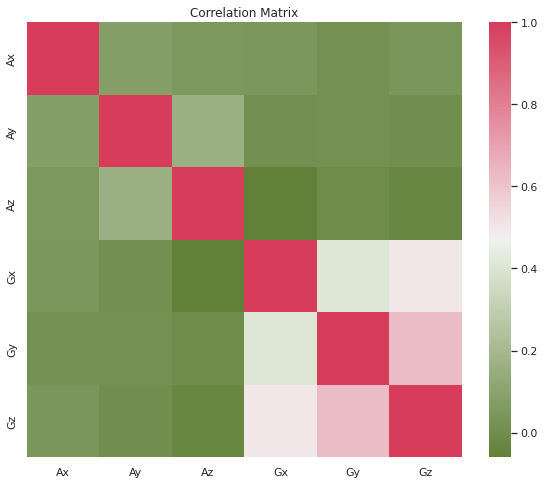

In [40]:
# Correlation matrix
CorrInfo = pd.DataFrame(user1,columns=['Ax','Ay', 'Az', 'Gx', 'Gy', 'Gz'])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

In [41]:
user1["AxGy"] = np.sqrt(np.square(user1['Ax']) + np.square(user1['Gy']))
user1["Ayz"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Az']))
user1["AxGx"] = np.sqrt(np.square(user1['Ax']) + np.square(user1['Gx']))
user1["AxGy"] = np.sqrt(np.square(user1['Ax']) + np.square(user1['Gy']))
user1["AyGx"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Gx']))
user1["AyGy"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Gy']))
user1["AzGx"] = np.sqrt(np.square(user1['Az']) + np.square(user1['Gx']))
user1["Gzy"] = np.sqrt(np.square(user1['Gz']) + np.square(user1['Gy']) )

In [42]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(user1.corr()['target'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

target    1.000000
Gz        0.253695
Gx        0.233612
AyGx      0.207730
AzGx      0.198887
AxGx      0.153829
Gy        0.102994
Gzy       0.095642
Ax        0.058035
AyGy      0.051442
AxGy      0.030600
Az        0.019094
Ay        0.014114
Ayz       0.011591
Name: target, dtype: float64


# Modelo de red neuronal

In [43]:
features = ['Gz', 'Gx', 'AyGx', 'AzGx', 'AxGx', 'Gy', 'Gzy', 'Ax', 'AyGy']

In [44]:
X_orig = user1[features]
y = user1['target']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 4672
Número de columnas: 9


In [48]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = user1[features]
y = user1['target']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
model.add(LSTM(128))
model.add(Dense(3, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
2023-08-31 21:49:00.985076: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-31 21:49:00.985845: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype i

Epoch 1/20


2023-08-31 21:49:01.192400: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-31 21:49:01.193626: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-31 21:49:01.194522: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

50/59 [========================>.....] - ETA: 0s - loss: 1.0830 - accuracy: 0.3787

2023-08-31 21:49:02.949892: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-31 21:49:02.950733: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-31 21:49:02.951343: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

59/59 [==============================] - 2s 11ms/step - loss: 1.0810 - accuracy: 0.3848 - val_loss: 1.0391 - val_accuracy: 0.4674
Epoch 2/20
59/59 [==============================] - 0s 6ms/step - loss: 1.0297 - accuracy: 0.4608 - val_loss: 0.9875 - val_accuracy: 0.4856
Epoch 3/20
59/59 [==============================] - 0s 5ms/step - loss: 1.0188 - accuracy: 0.4755 - val_loss: 0.9862 - val_accuracy: 0.4898
Epoch 4/20
59/59 [==============================] - 0s 6ms/step - loss: 1.0085 - accuracy: 0.4747 - val_loss: 0.9769 - val_accuracy: 0.4898
Epoch 5/20
59/59 [==============================] - 0s 5ms/step - loss: 0.9994 - accuracy: 0.4870 - val_loss: 0.9750 - val_accuracy: 0.4888
Epoch 6/20
59/59 [==============================] - 0s 5ms/step - loss: 0.9974 - accuracy: 0.4937 - val_loss: 0.9733 - val_accuracy: 0.4973
Epoch 7/20
59/59 [==============================] - 0s 6ms/step - loss: 0.9998 - accuracy: 0.4822 - val_loss: 0.9713 - val_accuracy: 0.5005
Epoch 8/20
59/59 [============

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2023-08-31 21:49:09.463277: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-31 21:49:09.463866: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-31 21:49:09.464825: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

30/30 [==============================] - 0s 1ms/step
Accuracy: 0.5197860962566845
Precision: 0.5201835244110661
Recall: 0.5197860962566845
F1 Score: 0.5184692845863733


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels=['Caminar', 'Subir escaleras', 'Bajar escaleras']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

30/30 [==============================] - 0s 1ms/step
Label: 1, Caminar
Accuracy: 0.6192513368983957
Precision: 0.5121212121212121
Recall: 0.4642857142857143
F1 Score: 0.48703170028818443

Label: 2, Subir escaleras
Accuracy: 0.679144385026738
Precision: 0.5126050420168067
Recall: 0.5922330097087378
F1 Score: 0.5495495495495496

Label: 3, Bajar escaleras
Accuracy: 0.7411764705882353
Precision: 0.5403225806451613
Recall: 0.5114503816793893
F1 Score: 0.5254901960784314



/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

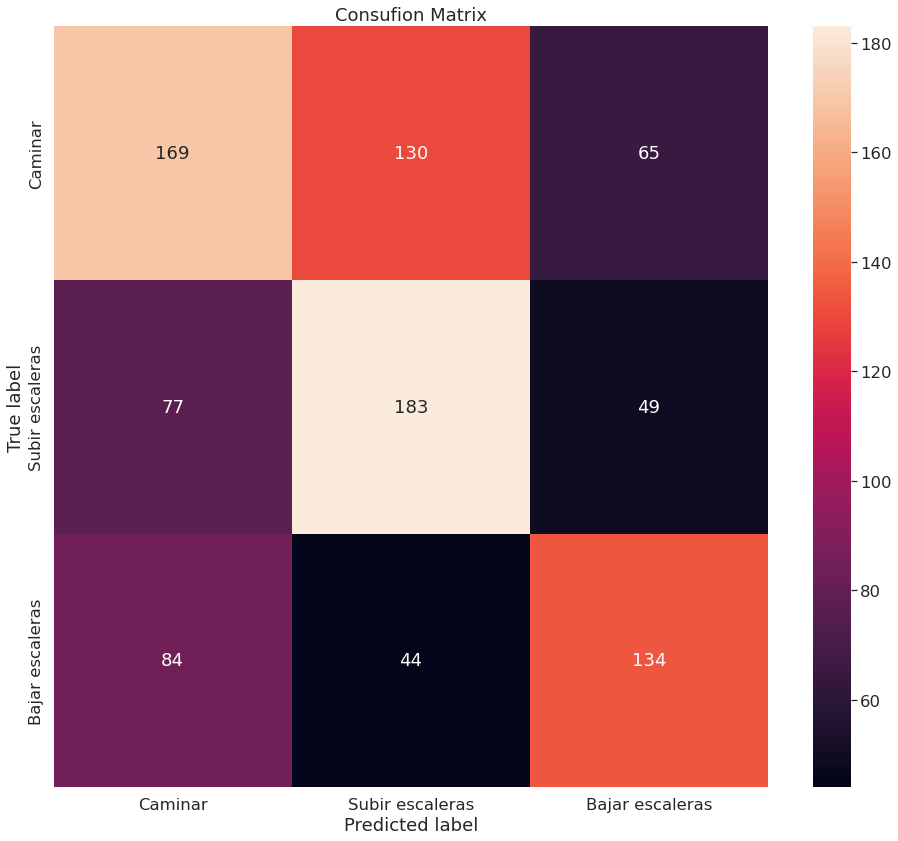

In [51]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [52]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 364, Actividad: Caminar
Valor: 1, Cantidad: 309, Actividad: Subir escaleras
Valor: 2, Cantidad: 262, Actividad: Bajar escaleras


# Exportamos el modelo

In [53]:
import joblib
# Guardamos el modelo entrenado
filename = 'Modelos/model_UCI-HAR.pkl' # Nombre del archivo donde se guardará el modelo
joblib.dump(model, filename) # Guardamos el modelo en un archivo
joblib.dump(label_encoder, 'Label/label_encoder_UCI-HAR.pkl')  # Guardar el LabelEncoder

['Label/label_encoder_UCI-HAR.pkl']